# 04b — Google Trends: expanding-window z-scores

Notebook 04 computed GT z-scores using the **full-panel** mean/std — a look-ahead bias because
the 2020 COVID spike inflates the std for all pre-COVID observations.

This notebook fixes that by replacing `gt_*_z`, `gt_*_d1`, and `gt_*_std3` with **expanding-window**
versions: at time T, the mean and std are computed from all months strictly before T (`shift(1)`).
`gt_*_yoy` is unaffected (it uses raw interest values, not z-scores).

Workflow:
1. Compute expanding z-scores on the **full** 9180-row GT panel (before any NaN filtering)
2. Load `panel_with_features.parquet`, drop old GT z-score columns, merge in the new ones
3. Re-apply the NaN drop and overwrite `panel_with_features.parquet`

Run this after notebook 04 whenever the raw Google Trends data changes.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

I = Path("../data/interim")
P = Path("../data/processed")

## Step 1 — Build expanding z-scores on full GT panel

In [2]:
# Load raw Google Trends and pivot to wide format
trends_long = pd.read_parquet(I / "google_trends_panel.parquet")
trends_long = trends_long.rename(columns={"month": "date"})

terms      = sorted(trends_long["term"].unique())
term_slugs = {t: "gt_" + t.replace(" ", "_") for t in terms}
gt_cols    = list(term_slugs.values())

trends_wide = (
    trends_long
    .pivot_table(index=["state_code", "date"], columns="term", values="interest", aggfunc="mean")
    .reset_index()
)
trends_wide.columns = ["state_code", "date"] + gt_cols

# Build a full-length anchor panel using LAUS dates so every state × month is present
laus = pd.read_parquet(I / "laus_panel_with_shocks.parquet")[["state_code", "date"]]
full = laus.merge(trends_wide, on=["state_code", "date"], how="left")
full = full.sort_values(["state_code", "date"]).reset_index(drop=True)

print(f"Full GT panel: {full.shape}  (should be 9180 rows)")

Full GT panel: (9180, 8)  (should be 9180 rows)


In [3]:
# Compute expanding z-scores: at time T, mean/std use only T-1, T-2, ... (shift(1))
# Derived features _d1 and _std3 are recomputed from the new z-scores automatically.
gt_z_cols = []
for col in gt_cols:
    exp_mean = full.groupby("state_code")[col].transform(lambda x: x.shift(1).expanding().mean())
    exp_std  = full.groupby("state_code")[col].transform(lambda x: x.shift(1).expanding().std().clip(lower=1e-8))
    full[f"{col}_z"]    = (full[col] - exp_mean) / exp_std
    full[f"{col}_d1"]   = full.groupby("state_code")[f"{col}_z"].transform(lambda x: x.diff(1))
    full[f"{col}_std3"] = full.groupby("state_code")[f"{col}_z"].transform(lambda x: x.rolling(3, min_periods=2).std())
    gt_z_cols += [f"{col}_z", f"{col}_d1", f"{col}_std3"]

# Sanity check: first few rows per state should be NaN (no prior history for expanding stats)
ak = full[full["state_code"] == "AK"][["date", "gt_unemployment_z"]]
print("AK — first 5 rows (expect NaN z-scores at start):")
print(ak.head())
print(f"\nTotal NaN z-scores (across all states/terms): {full['gt_unemployment_z'].isna().sum()}")

AK — first 5 rows (expect NaN z-scores at start):
        date  gt_unemployment_z
0 2010-01-01                NaN
1 2010-02-01                NaN
2 2010-03-01          -1.178511
3 2010-04-01          -0.560449
4 2010-05-01          -1.321656

Total NaN z-scores (across all states/terms): 102


## Step 2 — Merge into panel_with_features and overwrite

In [4]:
panel = pd.read_parquet(P / "panel_with_features.parquet")
print(f"Panel before update: {panel.shape}")

# Drop old globally-normalized GT columns
panel = panel.drop(columns=gt_z_cols)

# Merge in expanding z-score versions
new_gt = full[["state_code", "date"] + gt_z_cols]
panel  = panel.merge(new_gt, on=["state_code", "date"], how="left")

# Re-apply NaN drop (same logic as notebook 04)
id_cols     = ["state_code", "state_name", "date", "year", "month_of_year"]
target_cols = ["shock_sahm_03", "shock_sahm_05", "shock_sahm_07"]
check_cols  = [c for c in panel.columns if c not in id_cols + target_cols]

n_before = len(panel)
panel = panel.dropna(subset=check_cols)
n_after = len(panel)
print(f"Rows after NaN drop: {n_after}  (dropped {n_before - n_after} vs notebook 04 baseline of 765)")
print(f"Panel after update:  {panel.shape}")

panel.to_parquet(P / "panel_with_features.parquet", index=False)
print("\nOverwrote panel_with_features.parquet with expanding z-scores.")

Panel before update: (8415, 50)
Rows after NaN drop: 8415  (dropped 0 vs notebook 04 baseline of 765)
Panel after update:  (8415, 50)

Overwrote panel_with_features.parquet with expanding z-scores.


## Step 3 — Sanity check: z-scores should now be time-varying

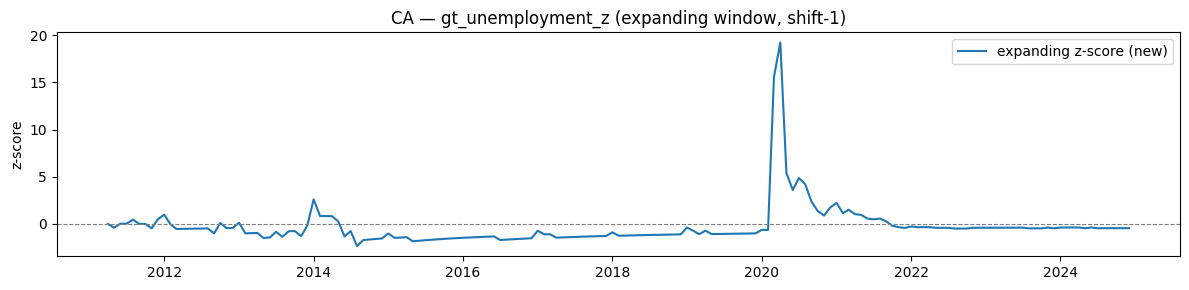

If the 2020 spike is still large but early values are not compressed, the fix worked.


In [5]:
import matplotlib.pyplot as plt

# Compare old (global) vs new (expanding) z-scores for one state/term
# Re-load to confirm saved version is correct
panel_check = pd.read_parquet(P / "panel_with_features.parquet")
ca = panel_check[panel_check["state_code"] == "CA"][["date", "gt_unemployment_z"]].set_index("date")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ca.index, ca["gt_unemployment_z"], lw=1.5, label="expanding z-score (new)")
ax.axhline(0, color="gray", lw=0.8, linestyle="--")
ax.set_title("CA — gt_unemployment_z (expanding window, shift-1)")
ax.set_ylabel("z-score")
ax.legend()
plt.tight_layout()
plt.show()
print("If the 2020 spike is still large but early values are not compressed, the fix worked.")